# Test on real world data

In [ ]:
from helper import *
import torch
import torchvision
import torchvision.transforms as transforms
import os
from torch.optim import Adam


from torch import nn
import numpy as np


In [ ]:
from torchvision.io import read_image, ImageReadMode

In [ ]:
def BIM(model, x, L_gt, S_gt, eps=0.1, alpha=0.1, steps=3, **kwargs):
    """
    The BIM (Basic Iterative Method) adversarial attack is a technique used to generate adversarial examples usually
     for machine learning models. This function aims to attack ADMM/ISTA optimizers.
    :param model: ADMM/ISTA object, the target machine learning model to be attacked.
    :param x: torch vector x - x=Hs+w s.t w~N(0,0.001)
    :param s_gt: torch vector which represents s^*
    :param eps:   A small perturbation magnitude that controls the strength of the attack
    :param alpha: A step size parameter for adjusting the perturbation at each iteration
    :param steps: The number of iterations to perform the attack.
    :return: adversarial x signal and the pertubation which was applied.
    """
    x = x.clone()#.to(device)
    L_gt, S_gt = L_gt.clone(), S_gt.clone()

    original_x = x.data
    original_x.requires_grad = False

    adv_x = x.clone().detach()

    for step in range(steps):

        print("#################### BIM Step {0} distance ratio: {1} ####################".format(step, ((adv_x - original_x).norm() / original_x.norm()).item()))

        adv_x.requires_grad = True

        loss, l_hat, s_hat = model(adv_x, **kwargs)
        # model.zero_grad()

        # Calculate loss
        cost = torch.linalg.norm(original_x - l_hat - s_hat, 'fro')
        print("#################### COST: {0} ####################".format(cost.item()/torch.linalg.norm(original_x, 'fro')))

        # cost.backward(retain_graph=True)
        grad = torch.autograd.grad(cost, adv_x)[0]

        # Grad is calculated
        delta = alpha * grad.sign()

        # Stop following gradient changes
        adv_x = adv_x.clone().detach()

        adv_x = adv_x + delta

        # Clip the change between the adversarial images and the original images to an epsilon range
        eta = torch.clamp(adv_x - original_x, min=-eps, max=eps)

        adv_x = original_x + eta

    return adv_x, delta  # grad is the gradient (perturbation)

In [ ]:
!git clone https://github.com/Harry24k/adversarial-attacks-pytorch

fatal: destination path 'adversarial-attacks-pytorch' already exists and is not an empty directory.


In [ ]:
# import sys
# sys.path.append("/content/adversarial-attacks-pytorch/torchattacks")
# import torchattacks

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import sys


device = "cpu"

def carlini_wagner(model, M_gt, c, steps, lr, **kwargs):

    M_gt = M_gt.clone().detach().to(device)


    # w = torch.zeros_like(images).detach() # Requires 2x times
    w = inverse_tanh_space(M_gt).detach()
    w.requires_grad = True

    MSELoss = nn.MSELoss(reduction="none")
    Flatten = nn.Flatten()

    optimizer = optim.Adam([w], lr=lr)

    for step in range(steps):
        # Get adversarial images
        adv_M = tanh_space(w)

        # Calculate loss
        current_L2 = MSELoss(Flatten(adv_M), Flatten(M_gt)).sum(dim=1)
        L2_loss = current_L2.sum()

        model_loss, L0_adv, S0_adv = AccAltProj(adv_M, **kwargs)
        outputs = L0_adv+S0_adv

        f_loss = f(outputs, M_gt).sum()

        cost = L2_loss + c * f_loss

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()
        print("### COST ",model_loss[-1].item(), L2_loss.item(),  c*f_loss.item(), "###")


    return adv_M, L0_adv, S0_adv

def tanh_space(x):
    return 1 / 2 * (torch.tanh(x) + 1)

def inverse_tanh_space(x):
    # torch.atanh is only for torch >= 1.7.0
    # atanh is defined in the range -1 to 1
    return atanh(torch.clamp(x * 2 - 1, min=-1, max=1))

def atanh(x):
    return 0.5 * torch.log((1 + x) / (1 - x))

# f-function in the paper
def f(outputs, labels):
  # current_fro = torch.linalg.norm(original_x - l_hat - s_hat, 'fro')
    # loss = nn.MSELoss
    # if outputs.shape!=labels.shape:
    #     cost = loss(outputs, labels.T)
    # else:
    cost = torch.linalg.norm(outputs - labels,'fro')

    return -1*cost



In [ ]:
# Before this one, drag the zip file to the current directory
!unzip data_pngs.zip -d data_pngs

Archive:  data_pngs.zip
   creating: data_pngs/data_pngs/
   creating: data_pngs/data_pngs/subject01/
  inflating: data_pngs/data_pngs/subject01/subject01_centerlight.png  
  inflating: data_pngs/data_pngs/subject01/subject01_glasses.png  
  inflating: data_pngs/data_pngs/subject01/subject01_happy.png  
  inflating: data_pngs/data_pngs/subject01/subject01_leftlight.png  
  inflating: data_pngs/data_pngs/subject01/subject01_noglasses.png  
  inflating: data_pngs/data_pngs/subject01/subject01_normal.png  
  inflating: data_pngs/data_pngs/subject01/subject01_rightlight.png  
  inflating: data_pngs/data_pngs/subject01/subject01_sad.png  
  inflating: data_pngs/data_pngs/subject01/subject01_sleepy.png  
  inflating: data_pngs/data_pngs/subject01/subject01_surprised.png  
  inflating: data_pngs/data_pngs/subject01/subject01_wink.png  
   creating: data_pngs/data_pngs/subject02/
  inflating: data_pngs/data_pngs/subject02/subject02_centerlight.png  
  inflating: data_pngs/data_pngs/subject02/s

In [ ]:
dir = "/content/data_pngs/data_pngs"
subjects = {}
for subject in os.listdir(dir):
    for pic in os.listdir(os.path.join(dir, subject)):
        f = os.path.join(dir, subject, pic)
        img = read_image(f, ImageReadMode.GRAY)
        img = torchvision.transforms.ConvertImageDtype(torch.float64)(img)
        img = torch.flatten(img.squeeze().T)
        if subjects.get(subject) == None:
            subjects[subject] = img
        else:
            subjects[subject] = torch.column_stack((subjects[subject], img))

## New functions

In [ ]:
def thres(inputs, t, hard=True, old=True):
    if not hard:
        out = torch.sign(inputs) * torch.max(torch.abs(inputs)- t, torch.zeros(inputs.shape))
    else:
        if old:
            out = inputs * (torch.abs(inputs) > t)
        else:
            # out = torch.sign(inputs) * torch.max(\
            #                                     torch.abs(inputs) - torch.nan_to_num(torch.div(torch.pow(t, 6), torch.pow(torch.abs(inputs), 5))) \
            #                                     , torch.zeros(inputs.shape))
            # out = torch.sign(inputs) * torch.max(torch.abs(inputs) \
            #                                     - torch.div(t, torch.exp(3 * torch.div(torch.abs(inputs) - t, t))) \
            #                                     , torch.zeros(inputs.shape))
            # out = inputs * torch.max(1 - torch.div(torch.pow(t, 2), torch.pow(inputs, 2)), torch.zeros(inputs.shape))
            # out = torch.div(1,  1 + torch.exp(-100 * (torch.sign(inputs) * torch.max(torch.abs(inputs)- t, torch.zeros(inputs.shape))))) \
            #         + torch.sign(inputs) * torch.max(torch.abs(inputs)- t, torch.zeros(inputs.shape)) \
            #         - t
            # mu = 1.0005 * t
            # out = inputs * (torch.abs(inputs) >= mu) \
            #         + torch.sign(inputs) * (mu/(mu-t))*(torch.abs(inputs) - t) * (mu > torch.abs(inputs)) * (torch.abs(inputs) >= t)
            gamma, beta = 0.95, 1
            out = inputs * (torch.abs(inputs) > torch.sqrt(gamma * beta * t**2)) * (beta <= gamma) \
                    + torch.sign(inputs) * torch.min(beta/(beta - gamma) * torch.max(torch.abs(inputs) - (t * gamma), torch.zeros(inputs.shape)), torch.abs(inputs)) * (beta > gamma)
    return out

In [ ]:
## ======================== Learned AccAltProj model ========================
## recover low-rank matrix L from M = L + S

class InitStage(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, M0, r):
        m, n = M0.shape
        norm_of_M0 = torch.linalg.norm(M0)
        beta = 1/(2 * np.power(m * n, 1/4))
        beta_init = 4 * beta
        zeta = beta_init * torch.linalg.norm(M0, 2)
        S = thres(M0, zeta, hard=True, old=False)
        U, Sigma, V = torch.linalg.svd(M0 - S, full_matrices=False)
        U, Sigma, V = U[:,:r], Sigma[:r], V.t()[:, :r]
        L = U @ torch.diag(Sigma) @ V.t()
        zeta = beta * Sigma[0]
        S = M0 - L
        S = thres(S, zeta, hard=True, old=False)
        return S, L, U, V, beta, norm_of_M0

class ProjStage(nn.Module):
    def __init__(self, gamma, lay):
        super().__init__()
        self.gamma = gamma
        self.lay = lay
    def forward(self, M0, S, U, V, r, beta):
        ## Update L
        Z = M0 - S
        Q1, R1 = torch.linalg.qr(Z.t() @ U - V @ ((Z @ V).t() @ U)) ## reduced QR
        Q2, R2 = torch.linalg.qr(Z @ V - U @ (U.t() @ Z @ V)) ## reduced QR
        A = torch.cat((torch.cat((U.t() @ Z @ V, R1.t()), 1),
                        torch.cat((R2, torch.zeros(R2.shape)), 1)), 0) ## A is 2r x 2r matrix
        Um, Sm, Vm = torch.linalg.svd(A, full_matrices=False)
        U = torch.cat((U, Q2), 1) @ Um[:,:r]
        V = torch.cat((V, Q1), 1) @ Vm.t()[:,:r]
        L = U @ torch.diag(Sm[:r]) @ V.t()
        ## Update S
        zeta = beta * (Sm[r] + torch.pow(self.gamma, self.lay) * Sm[0])
        S = M0 - L
        S = thres(S, zeta, hard=True, old=False)
        return S, L, U, V

class LearnedAAP(nn.Module):
    def __init__(self, max_iter, d1, d2):
        super().__init__()
        self.max_iter = max_iter
        self.gamma = nn.Parameter(torch.tensor(0.7))
        #self.gamma = torch.tensor(0.7)
        self.beta = nn.Parameter(torch.tensor(1/(2 * np.power(d1 * d2, 1/4))))

        ## Stack layers
        self.layer = [InitStage()]
        for t in range(max_iter):
            #self.layer.append(ProjStage(gamma = nn.Parameter(torch.pow(self.gamma.clone().detach(), t + 1).requires_grad_(True))))
            #self.layer.append(ProjStage(gamma = nn.Parameter(self.gamma.clone().detach().requires_grad_(True))))
            self.layer.append(ProjStage(self.gamma, t+1))
        self.layers = nn.Sequential(*self.layer)
        ## Track loss
        self.err = np.zeros(max_iter + 1)

    def forward(self, M0, r):
        lay_init = self.layers[0]
        S, L, U, V, beta, norm_of_M0 = lay_init(M0, r)
        for t in range(1, self.max_iter + 1):
            lay = self.layers[t]
            S, L, U, V = lay(M0, S, U, V, r, self.beta)
            self.err[t] = torch.linalg.norm(M0 - L - S)/ norm_of_M0
        return L, S

In [ ]:
def train_nn(net, r, lr, weight_decay, nepochs, dataset):
    torch.autograd.set_detect_anomaly(False)
    params_bftrain = [x.clone().detach().numpy() for x in list(net.parameters())]
    optimizer = Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    l0_norm_of_S_Shat = []
    for epoch in range(nepochs):
        for i in range(len(dataset)):
            L0, S0, M0 = dataset[i]
            optimizer.zero_grad()
            L_hat, S_hat = net(M0, r)
            print(net.err[-1])
            loss = torch.pow(torch.linalg.norm(L0 - L_hat), 2)/ torch.pow(torch.linalg.norm(L0), 2) \
                    + torch.pow(torch.linalg.norm(S0 - S_hat), 2)/ torch.pow(torch.linalg.norm(S0), 2) \
                    #+ torch.pow(torch.linalg.norm(M0 - L_hat - S_hat), 2)
            # loss = torch.linalg.norm(L0 - L_hat)/ torch.linalg.norm(L0) \
            #         + torch.linalg.norm(S0 - S_hat)/ torch.linalg.norm(S0)
            loss.backward()
            optimizer.step()
            l0_norm_of_S_Shat.append(torch.count_nonzero(S0 - S_hat))
            print(list(net.parameters()))
            print(net.gamma.grad, net.beta.grad)
            print('Epoch ' + str(epoch+1) +'/' + str(nepochs) +' at cost=' + str(loss.item()))
    print('Finished Training')
    params_aftrain = [x.clone().detach().numpy() for x in list(net.parameters())]
    return net, params_bftrain, params_aftrain, l0_norm_of_S_Shat

In [ ]:
def get_net_outputs(net_trained, net_bftrain, r, dataset):
    out_bftrain = []
    out_hat = []
    for i in range(len(dataset)):
        M_true = dataset[i]
        L_bftrain, S_bftrain = net_bftrain(M_true, r)
        print(net_bftrain.err[-1])
        out_bftrain.append((L_bftrain.detach().numpy(), S_bftrain.detach().numpy()))
        L_hat, S_hat = net_trained(M_true, r)
        print(net_trained.err[-1])
        out_hat.append((L_hat.detach().numpy(), S_hat.detach().numpy()))
    out_bftrain = np.asarray(out_bftrain)
    out_hat = np.asarray(out_hat)
    return out_bftrain, out_hat

In [ ]:
def plot_true_vs_est_matrices(L_hat, L_adv, L_true, S_hat, S_adv, S_true):
    combined = np.concatenate((L_hat, L_adv, L_true, S_hat, S_adv, S_true))
    #fig, [ax1, ax2] = plt.subplots(1,2)
    plt.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    plt.show()
    plt.imshow(L_adv, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax1.set_title("L_hat")
    #plt.colorbar(im1, ax=ax1)
    plt.show()
    plt.imshow(L_true, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax2.set_title("L_true")
    #plt.colorbar(im2, ax=ax2)
    plt.show()
    #fig, [ax3, ax4] = plt.subplots(1,2)
    plt.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    plt.show()

    plt.imshow(S_adv, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax3.set_title("S_hat")
    #plt.colorbar(im3, ax=ax3)
    plt.show()
    plt.imshow(S_true, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax4.set_title("S_true")
    #plt.colorbar(im4, ax=ax4)
    plt.show()

def plot_true_vs_est_matrices_original(L_hat, L_true, S_hat, S_true):
    combined = np.concatenate((L_hat, L_true, S_hat, S_true))
    #fig, [ax1, ax2] = plt.subplots(1,2)
    plt.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax1.set_title("L_hat")
    #plt.colorbar(im1, ax=ax1)
    plt.show()
    plt.imshow(L_true, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax2.set_title("L_true")
    #plt.colorbar(im2, ax=ax2)
    plt.show()
    #fig, [ax3, ax4] = plt.subplots(1,2)
    plt.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax3.set_title("S_hat")
    #plt.colorbar(im3, ax=ax3)
    plt.show()
    plt.imshow(S_true, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    #ax4.set_title("S_true")
    #plt.colorbar(im4, ax=ax4)
    plt.show()

In [ ]:
def resample(m, n, siz_row, siz_col):
    rows = np.random.randint(0, m, size=[1, siz_row])
    cols = np.random.randint(0, n, size=[1, siz_col])
    return [np.unique(rows), np.unique(cols)]

def AccAltProj(M0, r, tol, gamma, max_iter):
    m, n = M0.shape

    print(f"N: {n} M: {m}")


    norm_of_M0 = torch.linalg.norm(M0)
    ## Keep track of loss
    loss = []
    ## Initialization
    beta = 1/(2 * np.power(m * n, 1/4))
    beta_init = 4 * beta
    zeta = beta_init * torch.linalg.norm(M0, 2)
    S = thres(M0, zeta)#, False)
    U, Sigma, V = torch.linalg.svd(M0 - S, full_matrices=False)
    ## NOTE: torch.linalg.svd(M) returns U, S, V such that M=USV not USV.T
    U, Sigma, V = U[:,:r], Sigma[:r], V.t()[:, :r]
    L = U @ torch.diag(Sigma) @ V.t()
    zeta = beta * Sigma[0]
    S = thres(M0 - L, zeta)#, False)
    ## Initial loss
    err = torch.linalg.norm(M0 - L - S)/ norm_of_M0
    loss.append(err)
    for t in range(max_iter):
        ## Update L
        Z = M0 - S
        Q1, R1 = torch.linalg.qr(Z.t() @ U - V @ ((Z @ V).t() @ U)) ## reduced QR
        Q2, R2 = torch.linalg.qr(Z @ V - U @ (U.t() @ Z @ V)) ## reduced QR
        A = torch.cat((torch.cat((U.t() @ Z @ V, R1.t()), 1),
                        torch.cat((R2, torch.zeros(R2.shape)), 1)), 0) ## A is 2r x 2r matrix
        Um, Sigma, Vm = torch.linalg.svd(A, full_matrices=False)
        U = torch.cat((U, Q2), 1) @ Um[:,:r]
        V = torch.cat((V, Q1), 1) @ Vm.t()[:,:r]
        L = U @ torch.diag(Sigma[:r]) @ V.t()
        ## Update S
        zeta = beta * (Sigma[r] + torch.pow(gamma, t + 1) * Sigma[0])
        S = thres(M0 - L, zeta)#, False)
        ## Compute error
        err = torch.linalg.norm(M0 - L - S)/ norm_of_M0
        loss.append(err)
        if err < tol:
            return loss, L, S
    return loss, L, S



## returns: loss, L, S
def IRCUR(M0, r, tol, gamma, con, max_iter):
    m, n = M0.shape
    norm_of_M0 = torch.linalg.norm(M0)
    ## Keep track of loss
    loss = []
    ## Initialization
    siz_row, siz_col = np.ceil(con * r * np.log(m)).astype(np.int64), np.ceil(con * r * np.log(n)).astype(np.int64)
    zeta = torch.max(torch.abs(M0))
    C, pinv_U, R = torch.zeros(M0.shape), torch.zeros([M0.shape[1], M0.shape[0]]), torch.zeros(M0.shape)
    for t in range(max_iter):
        ## resample rows and columns
        rows, cols = resample(m, n, siz_row, siz_col)
        M0_rows = M0[rows, :]
        M0_cols = M0[:, cols]
        norm_of_M0 = torch.linalg.norm(M0_rows) + torch.linalg.norm(M0_cols)
        ## compute submatrices of L from previous iteration
        L_rows = C[rows, :] @ pinv_U @ R
        L_cols = C @ pinv_U @ R[:, cols]
        ## update S using submatrices of L
        S_rows = thres(M0_rows - L_rows, zeta)
        S_cols = thres(M0_cols - L_cols, zeta)
        ## update L
        C = M0_cols - S_cols
        R = M0_rows - S_rows
        MU = C[rows, :]
        U,Sigma,Vh = torch.linalg.svd(MU, full_matrices=False)
        ## calculate Moore-Penrose inverse of Sigma
        pinv_U = Vh.t()[:,:r] @ torch.diag(1./Sigma[:r]) @ U[:, :r].t()
        ## update zeta
        zeta = gamma * zeta
        ## update loss
        err = (torch.linalg.norm(M0_rows - L_rows - S_rows) + torch.linalg.norm(M0_cols - L_cols - S_cols))/ norm_of_M0
        loss.append(err)
        if err < tol:
            L = C @ pinv_U @ R
            S = thres(M0 - L, zeta)
            return loss, L, S
    L = C @ pinv_U @ R
    S = thres(M0 - L, zeta)
    return loss, L, S

## Training

In [ ]:
r = 1
max_iter = 50

In [ ]:
print("original beta =", 1/(2 * np.power(243 * 320 * 11, 1/4)))

original beta = 0.01644117189829903


In [ ]:
train = [subjects[x] for x in ['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07']]
test = [subjects[x] for x in ['subject08', 'subject09', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 'subject15']]

In [ ]:


train_est = []
for i, M_true in enumerate(train):
    loss, L0, S0 = IRCUR(M_true, r, 1e-06, torch.tensor(0.7), 3, max_iter)
    train_est.append((L0, S0, M_true))
    print(loss[-1])

tensor(6.6343e-07, dtype=torch.float64)
tensor(9.3468e-07, dtype=torch.float64)
tensor(8.6695e-07, dtype=torch.float64)
tensor(5.8314e-07, dtype=torch.float64)
tensor(9.2251e-07, dtype=torch.float64)
tensor(5.7771e-07, dtype=torch.float64)
tensor(7.2016e-07, dtype=torch.float64)


In [ ]:
net, params_bftrain, params_aftrain, l0_norm_of_S_Shat = train_nn(LearnedAAP(max_iter, 243 * 320, 11), r \
                                                                    , lr=2e-04, weight_decay=0 \
                                                                    , nepochs=8, dataset=train_est)

9.526989247319585e-09
[Parameter containing:
tensor(0.7002, requires_grad=True), Parameter containing:
tensor(0.0166, dtype=torch.float64, requires_grad=True)]
tensor(-7.9711) tensor(-38.8056, dtype=torch.float64)
Epoch 1/8 at cost=0.0429716106904294
1.997304783128484e-08
[Parameter containing:
tensor(0.7003, requires_grad=True), Parameter containing:
tensor(0.0168, dtype=torch.float64, requires_grad=True)]
tensor(0.2886) tensor(1.1436, dtype=torch.float64)
Epoch 1/8 at cost=0.039411027015441816
1.5054454662040028e-08
[Parameter containing:
tensor(0.7003, requires_grad=True), Parameter containing:
tensor(0.0167, dtype=torch.float64, requires_grad=True)]
tensor(16.2975) tensor(56.3975, dtype=torch.float64)
Epoch 1/8 at cost=0.4722765826852212
1.963546115213555e-08
[Parameter containing:
tensor(0.7002, requires_grad=True), Parameter containing:
tensor(0.0167, dtype=torch.float64, requires_grad=True)]
tensor(-0.0062) tensor(-0.3648, dtype=torch.float64)
Epoch 1/8 at cost=0.069195327987776

## on train data

In [ ]:
out_bftrain, out_hat = get_net_outputs(net, LearnedAAP(max_iter, 243 * 320, 11), r, train)

9.526989247319585e-09
9.26311513010098e-09
1.8903061077035238e-08
1.414109972809143e-08
1.494700518386155e-08
1.4602174488111247e-08
1.9849326814709276e-08
1.6242445523593208e-08
1.371990732179434e-08
1.3543333154193007e-08
2.2113440969125774e-08
1.5420012764570024e-08
9.312456585149392e-09
8.456611225722183e-09


In [ ]:

out_hat[0][0].shape

(77760, 11)

In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage import io, img_as_float
import cv2

def mse(imageA, imageB):
    # Mean Squared Error between two images
    # pdb.set_trace()
    err = np.mean((imageA - imageB) ** 2)
    return err

def compare_images(imageA, imageB):
    imageA = imageA.detach().numpy()
    imageB = imageB.detach().numpy()

    # Ensure same size
    if imageA.shape != imageB.shape:
        raise ValueError(f"Image shapes not matching: {imageA.shape} vs {imageB.shape}")

    # Compute metrics
    mse_value = mse(imageA, imageB)

    # For SSIM: handle grayscale or color
    if len(imageA.shape) == 2:
        ssim_value = ssim(imageA, imageB, data_range=imageA.max() - imageA.min())
    else:
        ssim_value = ssim(imageA, imageB, channel_axis=-1, data_range=imageA.max() - imageA.min())

    return ssim_value, mse_value





In [ ]:
import numpy as np

def hoyer_sparsity(x: np.ndarray) -> float:
    """
    Compute Hoyer's sparsity measure for a 2D numpy array.
    Input: x of shape (77760, 11) or any shape.
    """
    x = x.astype(np.float64).ravel()  # flatten to 1D
    n = len(x)

    l1 = np.linalg.norm(x, 1)
    l2 = np.linalg.norm(x, 2)

    if l2 == 0:  # all-zero case
        return 0.0

    sparsity = (np.sqrt(n) - (l1 / l2)) / (np.sqrt(n) - 1)
    return sparsity

def l0_sparsity(x: np.ndarray) -> float:
    """
    Compute Hoyer's sparsity measure for a 2D numpy array.
    Input: x of shape (77760, 11) or any shape.
    """
    x = x.astype(np.float64).ravel()  # flatten to 1D
    n = len(x)
    return sum((x==0))/n


In [ ]:
#### SAME AS THE NEXT CELL BUT MEASURING epsilon vs distortion

import pdb
import matplotlib.pyplot as plt
from collections import defaultdict
out_accaltproj = []
out_accaltproj_adv = []
# ssim_per
IMAGE_INDEX = 1
eps_lst = [0.01, 0.02, 0.03, 0.04, 0.05]

L_ssim_per_eps = defaultdict(list)
S_ssim_per_eps = defaultdict(list)

L_mse_per_eps = defaultdict(list)
S_mse_per_eps = defaultdict(list)

loss_per_eps = dict.fromkeys(eps_lst, 0)


for eps in eps_lst:
  for i, M_true in enumerate(train):
    #pdb.set_trace()
    loss, L0, S0 = AccAltProj(M_true, r, 1e-06, torch.tensor(0.7), max_iter)
    import pdb
    pdb.set_trace()
    print(f"s_gt sparsity: {(l0_sparsity(S0.detach().numpy()))}")
    # Effective rank
    u, s, vh = np.linalg.svd(L0, full_matrices=False)
    p = s / s.sum()
    effective_rank = np.exp(-(p * np.log(p)).sum())
    print("Effective rank:", effective_rank)
    # pdb.set_trace()
    print(f"original L0 RANK: {np.linalg.matrix_rank(L0)}")

    kwargs = {'r': r, 'tol': 1e-06, 'gamma': torch.tensor(0.7), 'max_iter': max_iter}
    # pdb.set_trace()
    adv_M, _ = BIM(AccAltProj, M_true, L0, S0, alpha=0.01, steps=5,eps=eps, **kwargs)


    # adv_M, _, _ = carlini_wagner(AccAltProj, M_true, c=8.8*10**5, lr=0.01, steps=20, **kwargs)

    # Plotting adv_m
    # adv_M
    # pdb.set_trace()
    combined = np.concatenate((adv_M[:,IMAGE_INDEX].detach().numpy(), M_true[:,IMAGE_INDEX].detach().numpy()))
    adv_M_numpy = adv_M.detach().numpy()
    plt.imshow(M_true[:,IMAGE_INDEX].reshape(320, 243).T, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    plt.show()
    plt.imshow(adv_M_numpy[:,IMAGE_INDEX].reshape(320,243).T, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
    # pdb.set_trace()
    plt.show()
    print(np.min(M_true[:,IMAGE_INDEX].detach().numpy()))
    print(np.max(M_true[:,IMAGE_INDEX].detach().numpy()))

    loss_adv, l_adv, s_adv = AccAltProj(adv_M, r, 1e-06, torch.tensor(0.7), max_iter)
    print(f"S_adv sparsity: {(l0_sparsity(s_adv.detach().numpy()))}")
    # Effective rank
    u, s, vh = np.linalg.svd(l_adv, full_matrices=False)
    p = s / s.sum()
    effective_rank = np.exp(-(p * np.log(p)).sum())
    print(f"adv l0 effective RANK: {effective_rank}")

    print(f"adv L0 RANK: {np.linalg.matrix_rank(l_adv)}")



    L_ssim_per_eps[eps], L_mse_per_eps[eps] = compare_images(l_adv, L0)
    S_ssim_per_eps[eps], S_mse_per_eps[eps] = compare_images(s_adv, S0)

    loss_per_eps[eps] += float(torch.linalg.norm(M_true - l_adv - s_adv)/ torch.linalg.norm(M_true))


    print(f"Loss gt {loss[-1]}")
    print(f"Loss adversarial {loss_adv[-1]}")
    out_accaltproj.append((L0, S0, M_true))
    out_accaltproj_adv.append([l_adv.detach().numpy(), s_adv.detach().numpy(), adv_M])

  loss_per_eps[eps]/=len(train)
  L_ssim_per_eps[eps]/=len(train)
  S_ssim_per_eps[eps]/=len(train)
  L_mse_per_eps[eps]/=len(train)
  S_mse_per_eps[eps]/=len(train)

N: 11 M: 77760
> /tmp/ipython-input-1627231403.py(27)<cell line: 0>()
     25     import pdb
     26     pdb.set_trace()
---> 27     print(f"s_gt sparsity: {(l0_sparsity(S0.detach().numpy()))}")
     28     # Effective rank
     29     u, s, vh = np.linalg.svd(L0, full_matrices=False)

tensor([[0.5098, 0.5098, 0.5098,  ..., 0.5098, 0.5098, 0.5098],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        ...,
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [0.2667, 0.2667, 0.2667,  ..., 0.2667, 0.2667, 0.2667]],
       dtype=torch.float64)
torch.Size([77760, 11])


<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2775834386.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("$\epsilon$")
/tmp/ipython-input-2775834386.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


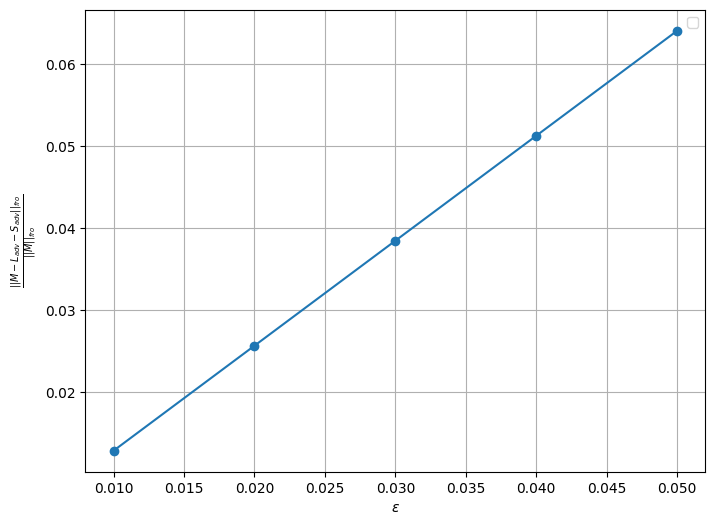

In [ ]:
loss_per_eps

dicts = [loss_per_eps]
# labels = ['loss_per_eps']
# Plot
plt.figure(figsize=(8,6))

for i, d in enumerate(dicts):
    keys = list(d.keys())
    values = [float(v) for v in d.values()]
    plt.plot(keys, values, marker='o',)# label=labels[i])

plt.xlabel("$\epsilon$")
#
plt.ylabel(r"$\frac{{||M - L_{adv} - S_{adv}||_{fro}}}{{||M||_{fro}}}$")
#plt.title("$|M_{gt} - L_{adv} - S_{adv}|/|M_{gt}|$")
plt.legend()
plt.grid(True)
fname="yale_decomposition.pdf"
plt.savefig(fname, bbox_inches='tight', format='pdf', transparent=True)
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2517715474.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("$\epsilon$")


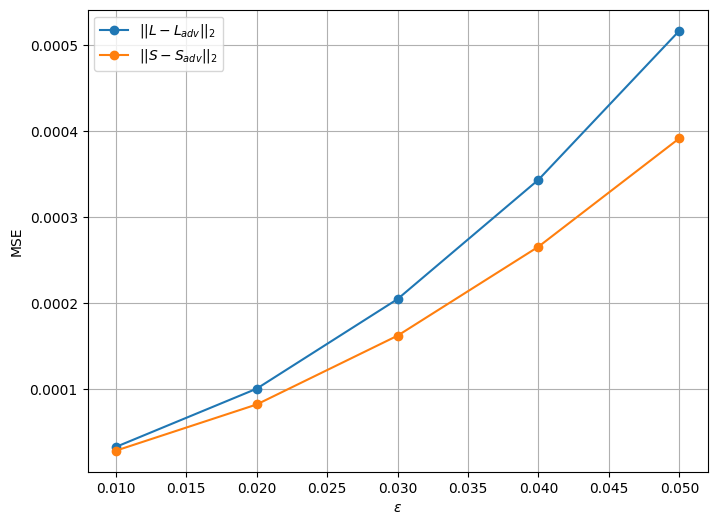

In [ ]:
L_ssim_per_eps

dicts = [L_mse_per_eps, S_mse_per_eps]
labels = ['$||L-L_{adv}||_{2}$', '$||S-S_{adv}||_{2}$']
# Plot
plt.figure(figsize=(8,6))

for i, d in enumerate(dicts):
    keys = list(d.keys())
    values = [float(v) for v in d.values()]
    plt.plot(keys, values, marker='o', label=labels[i])

plt.xlabel("$\epsilon$")
plt.ylabel("MSE")
# plt.title("MSE")
plt.legend()
plt.grid(True)
fname="yale_mse.pdf"
plt.savefig(fname, bbox_inches='tight', format='pdf', transparent=True)
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-1432967032.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("$\epsilon$")


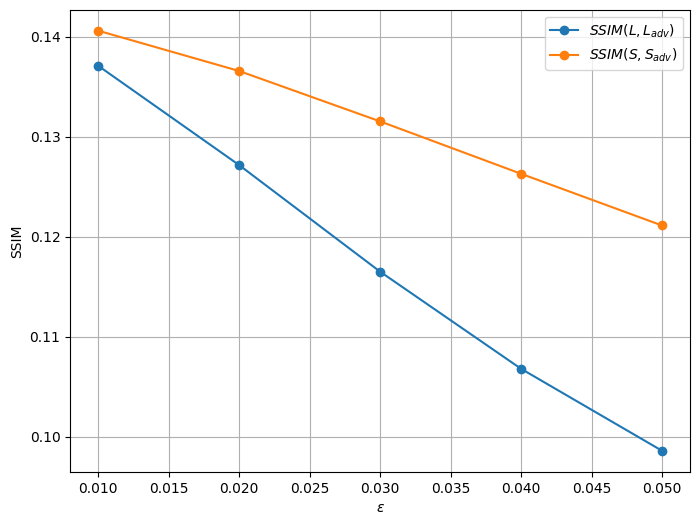

In [ ]:
L_ssim_per_eps

dicts = [L_ssim_per_eps, S_ssim_per_eps]
labels = ['$SSIM(L,L_{adv})$', '$SSIM(S,S_{adv})$']

# Plot
plt.figure(figsize=(8,6))

for i, d in enumerate(dicts):
    keys = list(d.keys())
    values = [float(v) for v in d.values()]
    plt.plot(keys, values, marker='o', label=labels[i])

plt.xlabel("$\epsilon$")
plt.ylabel("SSIM")
# plt.title("SSIM")
plt.legend()
plt.grid(True)
fname="yale_ssim.pdf"
plt.savefig(fname, bbox_inches='tight', format='pdf', transparent=True)

plt.show()

In [ ]:
loss_per_eps

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
def save_fig(fname,path):
    """
    The function saves the current figure to the specified file by using plt.savefig with the file path obtained by joining FIGURES_PATH and fname
    :param fname:  File name or path to save the figure.
    """
    plt.savefig(os.path.join(path, fname), bbox_inches='tight', format='pdf', transparent=True)

In [ ]:
# face_idx = 1
import os
x1=170
x2=200
y1=130
y2=180
def show_image(axs,img,secImg,face_idx,inset_limits, zoom_lvl=2.5, zoom_loc=2, inset_loc1=3, inset_loc2=4):
  x1,x2,y1,y2 = inset_limits
  combined = np.concatenate((img[:,face_idx], secImg[:,face_idx]))

  axs.imshow(img[:,face_idx].reshape(320, 243).T, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
  axs.get_xaxis().set_visible(False)
  axs.get_yaxis().set_visible(False)

  # zoomed image location
  axins = zoomed_inset_axes(axs, zoom_lvl, loc=zoom_loc)
  axins.imshow(img[:,face_idx].reshape(320, 243).T, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
  for axis in ['top','bottom','left','right']:
      axins.spines[axis].set_color('r')
  axins.set_xlim(x1, x2)
  axins.set_ylim(y1, y2)
  plt.xticks(visible=False)
  plt.yticks(visible=False)
  axins.invert_yaxis()
  # lines
  mark_inset(axs, axins, loc1= inset_loc1, loc2=inset_loc2, fc="none", ec='r', clip_on=False)

locations = { # person: -2
    #              x1  x2  y1  y2
    "nose"      : (170,200,110,160),
    "mouth"     : (150,220,160,200),
    "right_eye" : (195,245,90,125)
}
# locations = { # person: -1
#     #              x1  x2  y1  y2
#     "nose"      : (160,190,110,160),
#     "mouth"     : (150,220,160,200),
#     "right_eye" : (195,245,110,135)
# }
# Input/Pertubed - M, adv_M
# image number = 4
# M,L,S
# M_adv,L_adv,S_Adv
# 2X3 subplotsA

# TAKE ONLY ONE SUBJECT, Choose the old guy
image_number = 4
face_index = -2
def plot_images(person_index_list = [-2],face_index_list=[4],attack_name="BIM"):
  for person_idx in person_index_list:
    for face_idx in face_index_list:
      (L0, S0, M_true) = out_accaltproj[person_idx]
      [l_adv, s_adv, adv_M]=out_accaltproj_adv[person_idx]
      fig, axs = plt.subplots(2, 3)
      plt.subplots_adjust(wspace=0.1, hspace=0.1)
      import pdb

      # # pdb.set_trace()
      if type(M_true)==torch.Tensor:
        M_true = M_true.detach().numpy()
      if type(adv_M)==torch.Tensor:
        adv_M = adv_M.detach().numpy()

      show_image(axs[0,0],M_true,adv_M,face_idx,locations["nose"], zoom_lvl=2.8, zoom_loc=2, inset_loc1=1, inset_loc2=2)
      show_image(axs[1,0],adv_M,M_true,face_idx,locations["nose"], zoom_lvl=2.8, zoom_loc=2, inset_loc1=1, inset_loc2=2)
      show_image(axs[0,1],L0,l_adv,face_idx,locations["mouth"], zoom_lvl=2, zoom_loc=2, inset_loc1=3, inset_loc2=4)
      show_image(axs[1,1],l_adv,L0,face_idx,locations["mouth"], zoom_lvl=2, zoom_loc=2, inset_loc1=3, inset_loc2=4)
      show_image(axs[0,2],S0,s_adv,face_idx,locations["right_eye"], zoom_lvl=2.8, zoom_loc=2, inset_loc1=3, inset_loc2=4)
      show_image(axs[1,2],s_adv,S0,face_idx,locations["right_eye"], zoom_lvl=2.8, zoom_loc=2, inset_loc1=3, inset_loc2=4)
      if not os.path.isdir("plots"):
        os.mkdir("plots")
      save_fig("attack_RPCA_Yale_"+attack_name+".pdf","plots//")

all_persons = list(range(len(out_accaltproj)))
all_faces   = list(range(len(out_accaltproj[0][0][0,:])))
# plot_images(person_index_list=[0],face_index_list=[-2],attack_name="CW")
# plot_images(person_index_list=[0],face_index_list=[1])

plot_images(person_index_list=[-3],face_index_list=[-3],attack_name="BIM")

In [ ]:
import matplotlib.pyplot as plt

subject_num = 4

subject1_out_accaltproj = out_accaltproj[subject_num]
lowrank_out_accaltproj = subject1_out_accaltproj[0]
sparse_out_accaltproj = subject1_out_accaltproj[1]


subject1_out_accaltproj_adv = out_accaltproj_adv[subject_num]
lowrank_out_accaltproj_adv = subject1_out_accaltproj_adv[0]
sparse_out_accaltproj_adv = subject1_out_accaltproj_adv[1]

subject1_out_hat = out_hat[subject_num]
lowrank_out_hat = subject1_out_hat[0]
sparse_out_hat = subject1_out_hat[1]


subject1_train_est = train_est[subject_num]
lowrank_train_est = subject1_train_est[0]
sparse_train_est = subject1_train_est[1]

subject1_out_bftrain = out_bftrain[subject_num]
lowrank_out_bftrain = subject1_out_bftrain[0]
sparse_out_bftrain = subject1_out_bftrain[1]


for i in range(11):

    # remove lowrank_out_hat,  sparse_out_hat from here - and add the M_adv, M_ground-truth (do not plot all the 11 faces, only the first)
    plot_true_vs_est_matrices((lowrank_out_hat[:,i].reshape(320, 243).T) \
                            , (lowrank_out_accaltproj_adv[:,i].reshape(320, 243).T) \
                            , (lowrank_out_accaltproj[:,i].reshape(320, 243).T) \
                            , (sparse_out_hat[:,i].reshape(320, 243).T) \
                            , (sparse_out_accaltproj_adv[:,i].reshape(320, 243).T) \
                            , (sparse_out_accaltproj[:,i].reshape(320, 243).T))

## on test data

In [ ]:
print(list(net.parameters()))

In [ ]:
out_accaltproj_ontest = []
out_ircur_ontest = []
for i, M_true in enumerate(test):
    loss, L0, S0 = AccAltProj(M_true, r, 1e-06, torch.tensor(0.7), max_iter)
    print(loss[-1])
    out_accaltproj_ontest.append((L0, S0, M_true))
    loss, L0, S0 = IRCUR(M_true, r, 1e-06, torch.tensor(0.7), 3, max_iter)
    out_ircur_ontest.append((L0, S0, M_true))

In [ ]:
out_bftrain_ontest, out_hat_ontest = get_net_outputs(net, LearnedAAP(max_iter, 243 * 320, 11), r, test)

In [ ]:
subject1_accaltproj_ontest = out_accaltproj_ontest[5]
subject1_ircur_ontest = out_ircur_ontest[5]
subject1_out_hat_ontest = out_hat_ontest[5]
subject1_out_bftrain_ontest = out_bftrain_ontest[5]
lowrank_accaltproj_ontest = subject1_accaltproj_ontest[0]
lowrank_ircur_ontest = subject1_ircur_ontest[0]
lowrank_out_hat_ontest = subject1_out_hat_ontest[0]
lowrank_out_bftrain_ontest = subject1_out_bftrain_ontest[0]
sparse_accaltproj_ontest = subject1_accaltproj_ontest[1]
sparse_ircur_ontest = subject1_ircur_ontest[1]
sparse_out_hat_ontest = subject1_out_hat_ontest[1]
sparse_out_bftrain_ontest = subject1_out_bftrain_ontest[1]
for i in range(11):
    plot_true_vs_est_matrices_original((lowrank_out_hat_ontest[:,i].reshape(320, 243).T * 255) \
                            , (lowrank_ircur_ontest[:,i].reshape(320, 243).T * 255) \
                            , (sparse_out_hat_ontest[:,i].reshape(320, 243).T * 255) \
                            , (sparse_ircur_ontest[:,i].reshape(320, 243).T * 255))

In [ ]:
L_hat = (lowrank_out_hat_ontest[:,6].reshape(320, 243).T * 255)
S_hat = (sparse_out_hat_ontest[:,6].reshape(320, 243).T * 255)
L_ircur = (lowrank_ircur_ontest[:,6].reshape(320, 243).T * 255)
S_ircur = (sparse_ircur_ontest[:,6].reshape(320, 243).T * 255)
L_accaltproj = (lowrank_accaltproj_ontest[:,6].reshape(320, 243).T * 255)
S_accaltproj = (sparse_accaltproj_ontest[:,6].reshape(320, 243).T * 255)

combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))
plt.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.savefig('plots/face_unrolled_lr.eps', format='eps')
plt.show()
# plt.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
# plt.savefig('plots/face_ircur_lr.eps', format='eps')
# plt.show()
plt.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.savefig('plots/face_accaltproj_lr.eps', format='eps')
plt.show()
plt.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.savefig('plots/face_unrolled_sad.eps', format='eps')
plt.show()
# plt.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
# plt.savefig('plots/face_ircur_sad.eps', format='eps')
# plt.show()
plt.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.savefig('plots/face_accaltproj_sad.eps', format='eps')
plt.show()

# plot_true_vs_est_matrices((lowrank_out_hat_ontest[:,i].reshape(320, 243).T * 255) \
#                         , (lowrank_ircur_ontest[:,i].reshape(320, 243).T * 255) \
#                         , (sparse_out_hat_ontest[:,i].reshape(320, 243).T * 255) \
#                         , (sparse_ircur_ontest[:,i].reshape(320, 243).T * 255))

In [ ]:
L_hat = (lowrank_out_hat_ontest[:,2].reshape(320, 243).T * 255)
S_hat = (sparse_out_hat_ontest[:,2].reshape(320, 243).T * 255)
L_ircur = (lowrank_ircur_ontest[:,2].reshape(320, 243).T * 255)
S_ircur = (sparse_ircur_ontest[:,2].reshape(320, 243).T * 255)
L_accaltproj = (lowrank_accaltproj_ontest[:,2].reshape(320, 243).T * 255)
S_accaltproj = (sparse_accaltproj_ontest[:,2].reshape(320, 243).T * 255)

fig = plt.figure()
plt.imshow(L_hat-L_accaltproj.numpy(), cmap='gray')

fig = plt.figure()
plt.imshow(np.concatenate((L_hat, L_ircur, L_accaltproj), axis=1), cmap='gray')


fig = plt.figure()
plt.imshow(S_hat-S_accaltproj.numpy(), cmap='gray')

fig = plt.figure()
plt.imshow(np.concatenate((S_hat, S_ircur, S_accaltproj), axis=1), cmap='gray')

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

In [ ]:
L_hat = (lowrank_out_hat_ontest[:,2].reshape(320, 243).T * 255)
S_hat = (sparse_out_hat_ontest[:,2].reshape(320, 243).T * 255)
L_ircur = (lowrank_ircur_ontest[:,2].reshape(320, 243).T * 255)
S_ircur = (sparse_ircur_ontest[:,2].reshape(320, 243).T * 255)
L_accaltproj = (lowrank_accaltproj_ontest[:,2].reshape(320, 243).T * 255)
S_accaltproj = (sparse_accaltproj_ontest[:,2].reshape(320, 243).T * 255)


combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))

#where to zoom ?
x1=170
x2=200
y1=130
y2=180


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_lr.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_sad.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_sad.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_sad.eps', format='eps')


In [ ]:
L_hat = (lowrank_out_hat_ontest[:,2].reshape(320, 243).T * 255)
S_hat = (sparse_out_hat_ontest[:,2].reshape(320, 243).T * 255)
L_ircur = (lowrank_ircur_ontest[:,2].reshape(320, 243).T * 255)
S_ircur = (sparse_ircur_ontest[:,2].reshape(320, 243).T * 255)
L_accaltproj = (lowrank_accaltproj_ontest[:,2].reshape(320, 243).T * 255)
S_accaltproj = (sparse_accaltproj_ontest[:,2].reshape(320, 243).T * 255)


combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))

#where to zoom ?
x1=150
x2=180
y1=170
y2=200


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_lr.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_sad.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_sad.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_sad.eps', format='eps')


In [ ]:
L_hat = (lowrank_out_hat_ontest[:,2].reshape(320, 243).T * 255)
S_hat = (sparse_out_hat_ontest[:,2].reshape(320, 243).T * 255)
L_ircur = (lowrank_ircur_ontest[:,2].reshape(320, 243).T * 255)
S_ircur = (sparse_ircur_ontest[:,2].reshape(320, 243).T * 255)
L_accaltproj = (lowrank_accaltproj_ontest[:,2].reshape(320, 243).T * 255)
S_accaltproj = (sparse_accaltproj_ontest[:,2].reshape(320, 243).T * 255)


combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))

#where to zoom ?
x1=105
x2=130
y1=140
y2=180


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_13_unrolled_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_13_ircur_lr.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_13_accaltproj_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_13_unrolled_s_happy.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_13_ircur_s_happy.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_13_accaltproj_s_happy.eps', format='eps')

In [ ]:
L_hat = (lowrank_out_hat_ontest[:,2].reshape(320, 243).T * 255)
S_hat = (sparse_out_hat_ontest[:,2].reshape(320, 243).T * 255)
L_ircur = (lowrank_ircur_ontest[:,2].reshape(320, 243).T * 255)
S_ircur = (sparse_ircur_ontest[:,2].reshape(320, 243).T * 255)
L_accaltproj = (lowrank_accaltproj_ontest[:,2].reshape(320, 243).T * 255)
S_accaltproj = (sparse_accaltproj_ontest[:,2].reshape(320, 243).T * 255)


combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))

#where to zoom ?
x1=145
x2=215
y1=85
y2=100


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_lr.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_sad.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_sad.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_sad.eps', format='eps')


In [ ]:

subject1_accaltproj_ontest = out_accaltproj_ontest[2]
subject1_ircur_ontest = out_ircur_ontest[2]
subject1_out_hat_ontest = out_hat_ontest[2]
subject1_out_bftrain_ontest = out_bftrain_ontest[2]
lowrank_accaltproj_ontest = subject1_accaltproj_ontest[0]
lowrank_ircur_ontest = subject1_ircur_ontest[0]
lowrank_out_hat_ontest = subject1_out_hat_ontest[0]
lowrank_out_bftrain_ontest = subject1_out_bftrain_ontest[0]
sparse_accaltproj_ontest = subject1_accaltproj_ontest[1]
sparse_ircur_ontest = subject1_ircur_ontest[1]
sparse_out_hat_ontest = subject1_out_hat_ontest[1]
sparse_out_bftrain_ontest = subject1_out_bftrain_ontest[1]


In [ ]:
L_hat = (lowrank_out_hat_ontest[:,2].reshape(320, 243).T * 255)
S_hat = (sparse_out_hat_ontest[:,2].reshape(320, 243).T * 255)
L_ircur = (lowrank_ircur_ontest[:,2].reshape(320, 243).T * 255)
S_ircur = (sparse_ircur_ontest[:,2].reshape(320, 243).T * 255)
L_accaltproj = (lowrank_accaltproj_ontest[:,2].reshape(320, 243).T * 255)
S_accaltproj = (sparse_accaltproj_ontest[:,2].reshape(320, 243).T * 255)

fig = plt.figure()
plt.imshow(L_hat-L_accaltproj.numpy(), cmap='gray')

fig = plt.figure()
plt.imshow(np.concatenate((L_hat, L_ircur, L_accaltproj), axis=1), cmap='gray')


In [ ]:
combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))

#where to zoom ?
x1=100
x2=140
y1=90
y2=120

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_10_unrolled_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_10_ircur_lr.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_10_accaltproj_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_10_unrolled_s_happy.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_10_ircur_s_happy.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
plt.xticks(visible=False)
plt.yticks(visible=False)
axins = zoomed_inset_axes(ax, 2.5, loc=2)
axins.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/subject_10_accaltproj_s_happy.eps', format='eps')


In [ ]:
combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))

#where to zoom ?
x1=145#110
x2=200#160
y1=160#90
y2=195#140

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_lr.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_sad.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_sad.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_sad.eps', format='eps')


In [ ]:
combined = np.concatenate((L_hat, L_ircur, L_accaltproj, S_hat, S_ircur, S_accaltproj))

#where to zoom ?
x1=100
x2=140
y1=160
y2=210

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(L_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(L_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_lr.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 2, loc=2)
axins.imshow(L_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_lr.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_hat, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_unrolled_sad.eps', format='eps')


fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_ircur, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='r')
plt.savefig('plots/face_ircur_sad.eps', format='eps')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
axins = zoomed_inset_axes(ax, 3, loc=2)
axins.imshow(S_accaltproj, vmin=np.min(combined), vmax = np.max(combined), cmap='gray')
for axis in ['top','bottom','left','right']:
    axins.spines[axis].set_color('r')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
plt.xticks(visible=False)
plt.yticks(visible=False)
axins.invert_yaxis()
mark_inset(ax, axins, loc1=3, loc2=2, fc="none", ec='r')
plt.savefig('plots/face_accaltproj_sad.eps', format='eps')
